# Assignment 1: Exploratory Data Analysis (EDA) Machine Learning

### Dataset Description
Car Features and MSRP

 This Assignment  uses a car dataset containing various vehicle specifications and pricing information. The dataset is provided in CSV format and includes both numerical and categorical features that support comprehensive exploratory data analysis.

### Key Features:
- Make: Identifies the manufacturer .
- Model: Identifies specific model of the car.
- Year: Indicates the production year of the vehicle.
- Engine Fuel Type: Specifies the type of fuel used 
- Engine HP: Represents the engine horsepower .
- Engine Cylinders: Number of cylinders in the engine.
- Transmission Type: Shows whether the car uses manual or automatic transmission.
- Driven Wheels: Indicates the drivetrain configuration (FWD, RWD, AWD).
- Market Category: Describes the market segment (Luxury, Performance, High Performance).
- Vehicle Size: Classifies the car size (Compact, Midsize, Large). 
- Vehicle Style: Defines the body style (Coupe, Sedan, Convertible, SUV).
- city mpg: Fuel efficiency in urban, stop‑and‑go driving.
- highway MPG: Fuel efficiency during steady‑speed highway driving.
- Popularity: A numerical score indicating how popular the car model is. 
- MSRP: Manufacturer’s Suggested Retail Price, representing the vehicle’s market value.



### Dataset Size
- number of rows:  11194
- number of columns:  15

### Purpose of Using This Dataset 
This dataset was selected to perform data cleaning and exploratory data analysis . The main goal was to handle missing values, remove duplicates, fix data types, and prepare a clean and reliable dataset for analyzing how different car features such as engine power, fuel efficiency, and vehicle specifications relate to car prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
df = pd.read_csv("data.csv")

df.head(-1)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2011,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50520
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620


In [4]:
print(df.isna())

        Make  Model   Year  Engine Fuel Type  Engine HP  Engine Cylinders  \
0      False  False  False             False      False             False   
1      False  False  False             False      False             False   
2      False  False  False             False      False             False   
3      False  False  False             False      False             False   
4      False  False  False             False      False             False   
...      ...    ...    ...               ...        ...               ...   
11909  False  False  False             False      False             False   
11910  False  False  False             False      False             False   
11911  False  False  False             False      False             False   
11912  False  False  False             False      False             False   
11913  False  False  False             False      False             False   

       Transmission Type  Driven_Wheels  Number of Doors  Market Category  

In [5]:
print(df.isna().sum())

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [6]:
# handled missing values by filling categorical features using the mode and numerical features using the median. 
# The ‘Market Category’ column was dropped due to a large number of missing values and .
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].mode()[0])
df = df.drop(columns=['Market Category'], errors='ignore')

In [7]:
df.duplicated()[df.duplicated()==True]

14       True
18       True
20       True
24       True
25       True
         ... 
11481    True
11603    True
11604    True
11708    True
11717    True
Length: 720, dtype: bool

In [8]:
# Duplicate rows were removed .
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (11194, 15) 

number of rows:  11194
number of columns:  15


In [10]:
df.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

-  The columns were converted to integer type to ensure consistent and clean data for analysis.

In [11]:

df['Number of Doors'] = df['Number of Doors'].astype(int)
df['Engine Cylinders'] = df['Engine Cylinders'].astype(int)
df['Engine HP'] = df['Engine HP'].astype(int)

df.dtypes

Make                 object
Model                object
Year                  int64
Engine Fuel Type     object
Engine HP             int64
Engine Cylinders      int64
Transmission Type    object
Driven_Wheels        object
Number of Doors       int64
Vehicle Size         object
Vehicle Style        object
highway MPG           int64
city mpg              int64
Popularity            int64
MSRP                  int64
dtype: object

In [12]:
df.describe(include='all')

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
count,11194,11194,11194.000000,11194,11194.000000,11194.000000,11194,11194,11194.000000,11194,11194,11194.000000,11194.000000,11194.000000,1.119400e+04
unique,48,915,NaN,10,NaN,NaN,5,4,NaN,3,16,NaN,NaN,NaN,NaN
top,Chevrolet,Silverado 1500,NaN,regular unleaded,NaN,NaN,AUTOMATIC,front wheel drive,NaN,Compact,Sedan,NaN,NaN,NaN,NaN
freq,1083,156,NaN,6656,NaN,NaN,7928,4350,NaN,4393,2840,NaN,NaN,NaN,NaN
mean,NaN,NaN,2010.715026,NaN,253.227890,5.666696,NaN,NaN,3.454351,NaN,NaN,26.610238,19.732089,1557.964445,4.193329e+04
std,NaN,NaN,7.226875,NaN,109.849948,1.794883,NaN,NaN,0.872829,NaN,NaN,8.979206,9.179458,1445.449268,6.154731e+04
min,NaN,NaN,1990.000000,NaN,55.000000,0.000000,NaN,NaN,2.000000,NaN,NaN,12.000000,7.000000,2.000000,2.000000e+03
25%,NaN,NaN,2007.000000,NaN,172.000000,4.000000,NaN,NaN,2.000000,NaN,NaN,22.000000,16.000000,549.000000,2.159925e+04
50%,NaN,NaN,2015.000000,NaN,236.000000,6.000000,NaN,NaN,4.000000,NaN,NaN,25.000000,18.000000,1385.000000,3.067500e+04
75%,NaN,NaN,2016.000000,NaN,303.000000,6.000000,NaN,NaN,4.000000,NaN,NaN,30.000000,22.000000,2009.000000,4.303875e+04


In [13]:
df.isna().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

### Descriptive summary Statistics

-  Engine HP is right‑skewed with two peaks, showing two main horsepower categories.


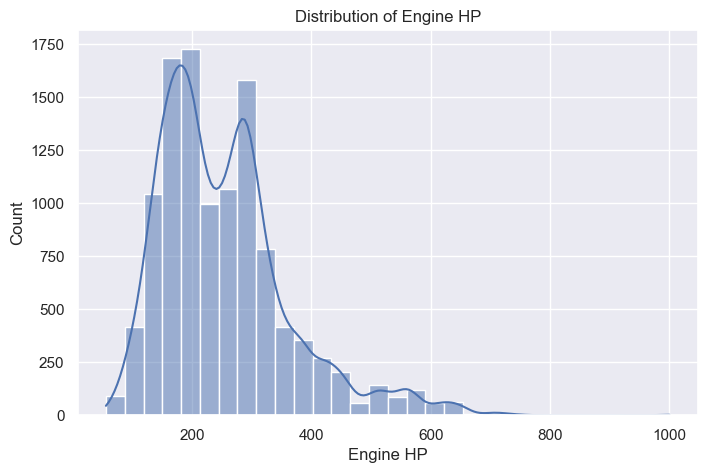

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Engine HP'], bins=30, kde=True)
plt.title("Distribution of Engine HP")
plt.show()

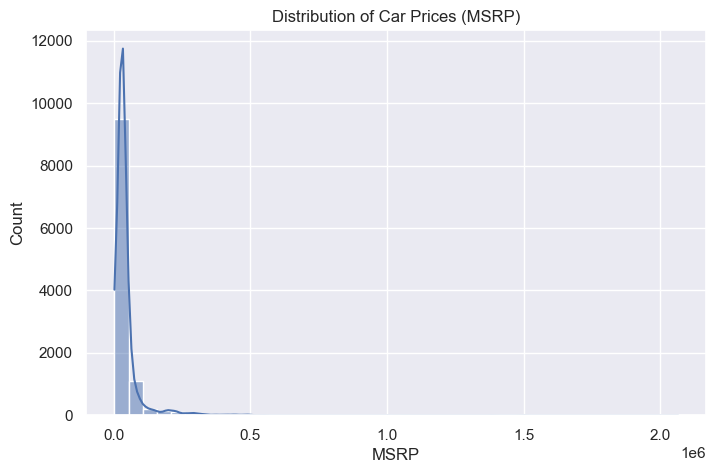

In [15]:
# Distribution of Car Prices (MSRP)
plt.figure(figsize=(8,5))
sns.histplot(df['MSRP'], bins=40, kde=True)
plt.title("Distribution of Car Prices (MSRP)")
plt.show()


-  Car prices show a strong right‑skewed distribution, with most vehicles priced at lower ranges and only a few extremely expensive models.

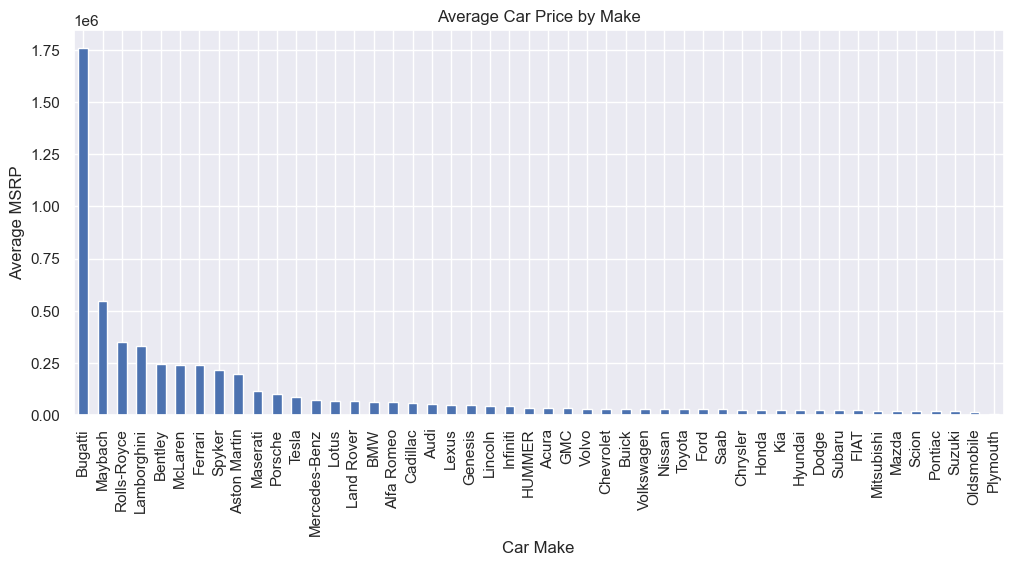

Make
Bugatti          1.757224e+06
Maybach          5.462219e+05
Rolls-Royce      3.511306e+05
Lamborghini      3.315673e+05
Bentley          2.471693e+05
McLaren          2.398050e+05
Ferrari          2.382188e+05
Spyker           2.149900e+05
Aston Martin     1.981235e+05
Maserati         1.136845e+05
Porsche          1.016224e+05
Tesla            8.525556e+04
Mercedes-Benz    7.206953e+04
Lotus            6.837714e+04
Land Rover       6.806709e+04
BMW              6.216256e+04
Alfa Romeo       6.160000e+04
Cadillac         5.636827e+04
Audi             5.457412e+04
Lexus            4.754907e+04
Genesis          4.661667e+04
Lincoln          4.386082e+04
Infiniti         4.264027e+04
HUMMER           3.646441e+04
Acura            3.508749e+04
GMC              3.244409e+04
Volvo            2.972468e+04
Chevrolet        2.907473e+04
Buick            2.903419e+04
Volkswagen       2.897852e+04
Nissan           2.892115e+04
Toyota           2.883599e+04
Ford             2.850811e+04
Saab 

In [16]:
make_price = df.groupby('Make')['MSRP'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
make_price.plot(kind='bar')
plt.title("Average Car Price by Make")
plt.ylabel("Average MSRP")
plt.xlabel("Car Make")
plt.show()

make_price



- the chart shows the average MSRP for each car manufacturer. Some luxury brands have significantly higher prices, while mass‑market brands tend to have lower average prices.

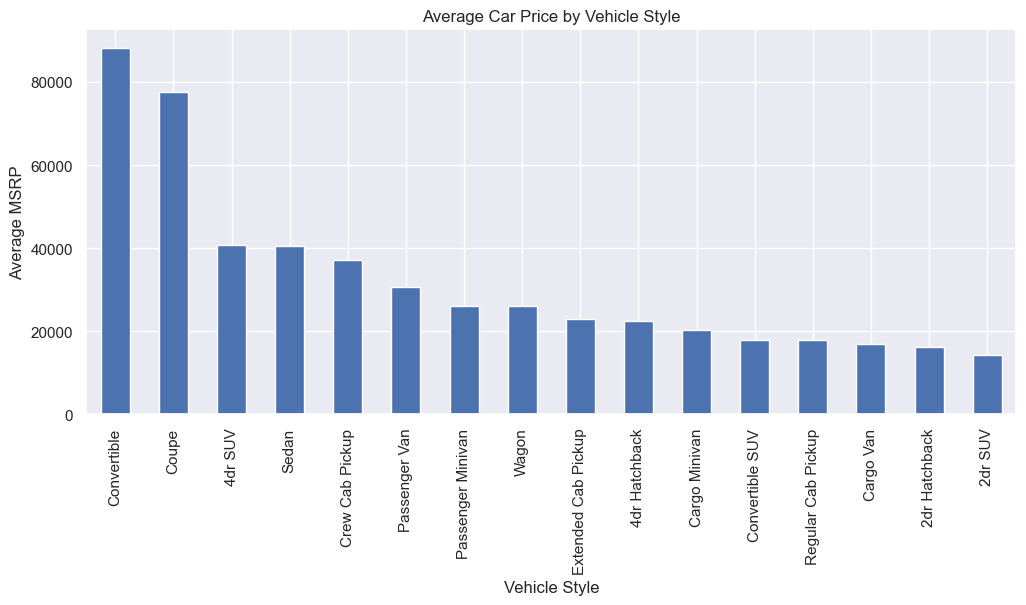

In [17]:
style_price = df.groupby('Vehicle Style')['MSRP'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
style_price.plot(kind='bar')
plt.title("Average Car Price by Vehicle Style")
plt.ylabel("Average MSRP")
plt.xlabel("Vehicle Style")
plt.show()


- Luxury styles (convertibles, coupes) show the highest average prices, while practical vehicle styles have noticeably lower MSRP.


### Make × MSRP & Vehicle Style × MSRP

In [18]:
make_price = df.groupby('Make')['MSRP'].mean().sort_values(ascending=False)
make_price.head(10)



Make
Bugatti         1.757224e+06
Maybach         5.462219e+05
Rolls-Royce     3.511306e+05
Lamborghini     3.315673e+05
Bentley         2.471693e+05
McLaren         2.398050e+05
Ferrari         2.382188e+05
Spyker          2.149900e+05
Aston Martin    1.981235e+05
Maserati        1.136845e+05
Name: MSRP, dtype: float64

- - The top car manufacturers by average price are dominated by luxury brands, which appear at the top of the ranking

In [19]:
style_price = df.groupby('Vehicle Style')['MSRP'].mean().sort_values(ascending=False)
style_price.head(10) 



Vehicle Style
Convertible            88216.792173
Coupe                  77595.287660
4dr SUV                40730.273624
Sedan                  40471.624296
Crew Cab Pickup        37192.344037
Passenger Van          30578.066116
Passenger Minivan      26176.562982
Wagon                  26156.939502
Extended Cab Pickup    23041.772194
4dr Hatchback          22416.467572
Name: MSRP, dtype: float64

- Luxury‑oriented vehicle styles such as convertibles and coupes have the highest average prices, while practical styles rank lower.

### Boxes vs Revenue Relationship


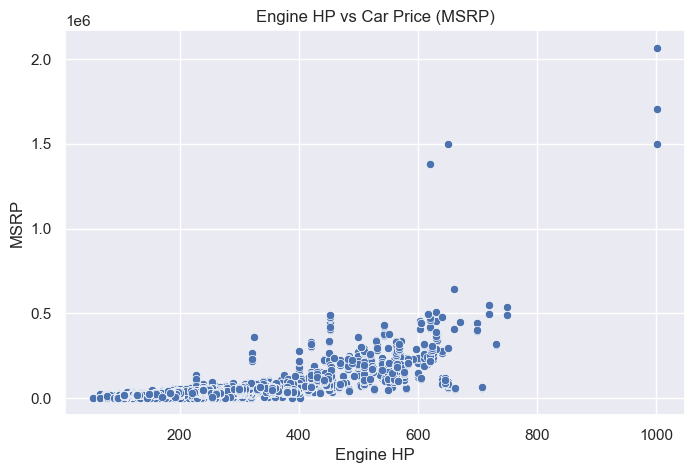

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Engine HP', y='MSRP', data=df)
plt.title("Engine HP vs Car Price (MSRP)")
plt.xlabel("Engine HP")
plt.ylabel("MSRP")
plt.show()


### Correlation Matrix


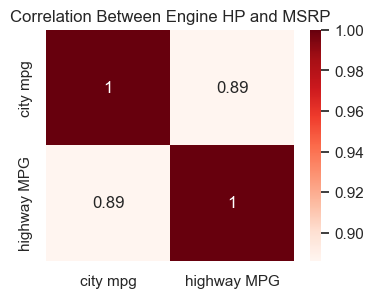

In [21]:
plt.figure(figsize=(4,3))
sns.heatmap(df[['city mpg', 'highway MPG']].corr(), annot=True, cmap='Reds')
plt.title("Correlation Between Engine HP and MSRP")
plt.show()



- The correlation value of 0.89 indicates a strong positive relationship between city mpg and highway mpg.

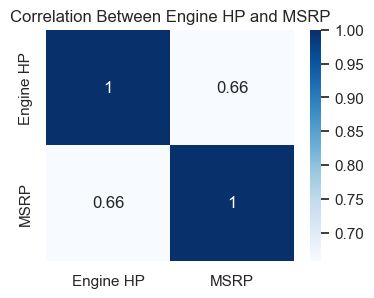

In [22]:
plt.figure(figsize=(4,3))
sns.heatmap(df[['Engine HP', 'MSRP']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Between Engine HP and MSRP")
plt.show()



- The correlation matrix reveals a moderately strong positive correlation (0.66) between Engine HP and MSRP, suggesting that higher‑horsepower vehicles are typically associated with higher prices.

### Yearly Car Count Trend

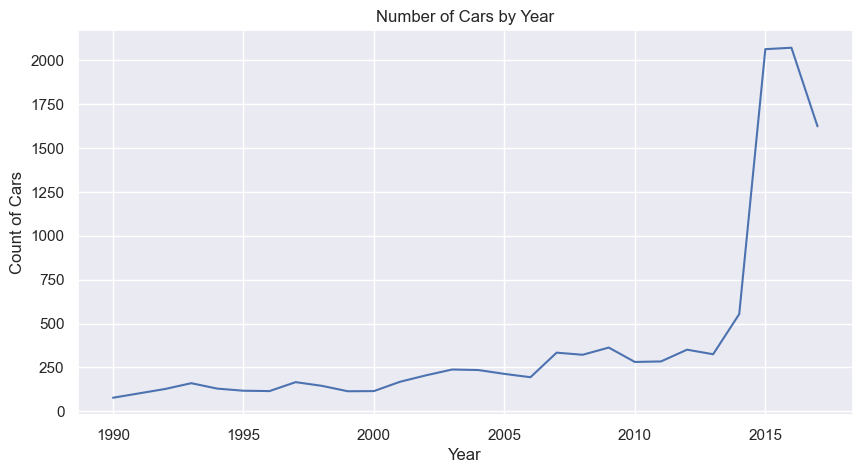

In [23]:
yearly_count = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_count.plot(kind='line')
plt.title("Number of Cars by Year")
plt.xlabel("Year")
plt.ylabel("Count of Cars")
plt.show()



- the trend shows how the number of available car models changes across different years.
- Some years have significantly more models, indicating higher production or dataset representation during those periods.

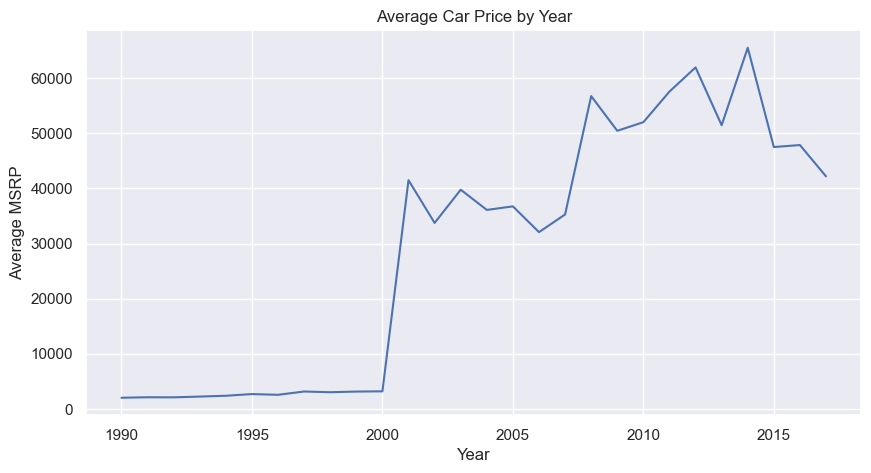

In [24]:
# Yearly Average Price Trend

yearly_price = df.groupby('Year')['MSRP'].mean()

plt.figure(figsize=(10,5))
yearly_price.plot(kind='line')
plt.title("Average Car Price by Year")
plt.xlabel("Year")
plt.ylabel("Average MSRP")
plt.show()
